# 00 · Exploration du schéma GDELT — Bénin Insights Challenge

**Hackathon iSHEERO × DataCamp 2026** 
**Objectif :** Explorer la structure des colonnes GDELT, identifier les variables pertinentes pour le ML, comprendre la taxonomie CAMEO

---

## Plan du notebook
1. Connexion BigQuery & extraction d'un échantillon Bénin
2. Inventaire des colonnes — types, valeurs nulles, distributions
3. Analyse des codes CAMEO (`EventRootCode`, `EventBaseCode`)
4. Distribution des variables cibles ML (`AvgTone`, `GoldsteinScale`)
5. Distribution des features catégorielles clés
6. Corrélations et relations inter-variables
7. Synthèse ML — variables retenues + modèles recommandés

> **Note :** Ce notebook utilise un échantillon de 5 000 événements (`LIMIT 5000`) pour préserver le quota BigQuery (1 TB/mois). Ne jamais lancer de requête sans filtre `YEAR`.

---
## 0 · Imports & configuration

In [8]:
# ── Imports standards ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Constante projet ──────────────────────────────────────────────────────
COUNTRY_CODE = 'BC'# Code FIPS10-4 du Bénin
YEAR_MIN = 2025
SAMPLE_LIMIT = 5000 # Quota BigQuery : toujours tester sur un échantillon

print(' Imports OK')

✅ Imports OK


---
## 1 · Connexion BigQuery & extraction de l'échantillon Bénin

** Règle d'or BigQuery :** 
Toujours filtrer `YEAR >= 2025` **en premier** dans la clause `WHERE`. 
La table `gdeltv2.events` fait plusieurs pétabytes — une requête sans filtre `YEAR` peut brûler le quota 1 TB en un seul appel.

**Alternatives offline (si connexion instable) :**
- Télécharger les fichiers CSV depuis [gdeltproject.org](https://www.gdeltproject.org/data.html)
- Utiliser le bloc *Option B* ci-dessous pour charger un CSV local

In [9]:
# ── Option A : BigQuery (connexion internet requise) ──────────────────────
USE_BIGQUERY = False # ← Mettre False pour charger un CSV local

if USE_BIGQUERY:
    try:
        from google.cloud import bigquery
        client = bigquery.Client() # Requiert une authentification gcloud

        query = f"""SELECT
                GLOBALEVENTID, SQLDATE, MONTHYEAR, YEAR,
                Actor1CountryCode, Actor1Type1Code, Actor1Name,
                Actor2CountryCode, Actor2Type1Code,
                EventRootCode, EventBaseCode, EventCode,
                GoldsteinScale, AvgTone,
                QuadClass, NumMentions, NumSources, NumArticles,
                ActionGeo_CountryCode, ActionGeo_FullName,
                ActionGeo_ADM1Code, ActionGeo_Lat, ActionGeo_Long,
                SOURCEURL
            FROM `gdelt-bq.gdeltv2.events`
            WHERE ActionGeo_CountryCode = '{COUNTRY_CODE}'AND YEAR >= {YEAR_MIN}
            LIMIT {SAMPLE_LIMIT}
        """# Estimation du coût avant exécution (dry_run)
        job_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
        dry_run_job = client.query(query, job_config=job_config)
        gb_scanned = dry_run_job.total_bytes_processed / 1e9
        print(f' Données scannées (estimation) : {gb_scanned:.2f} GB')

        # Exécution réelle
        df = client.query(query).to_dataframe()
        print(f' BigQuery : {len(df):,} événements extraits')

    except Exception as e:
        print(f' BigQuery indisponible : {e}')
        print('→ Basculement sur Option B (CSV local)')
        USE_BIGQUERY = False

if not USE_BIGQUERY:
    # ── Option B : CSV local (offline / backup) ───────────────────────────
    # Remplacer le chemin par votre fichier téléchargé depuis gdeltproject.org
    CSV_PATH = '/content/donnees_benin.csv'try:
        df = pd.read_csv(CSV_PATH, low_memory=False)
        # Filtre pays en cas de CSV multi-pays
        if 'ActionGeo_CountryCode' in df.columns:
            df = df[df['ActionGeo_CountryCode'] == COUNTRY_CODE].copy()
        print(f' CSV local : {len(df):,} événements chargés depuis {CSV_PATH}')
    except FileNotFoundError:
        print(' Fichier CSV introuvable. Vérifiez le chemin CSV_PATH.')
        raise

✅ CSV local : 13,137 événements chargés depuis /content/donnees_benin.csv


---
## 2 · Inventaire des colonnes — types, valeurs nulles, aperçu

In [10]:
# ── Aperçu général ────────────────────────────────────────────────────────
print(f'Dimensions du dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Période couverte : {df["SQLDATE"].min()} → {df["SQLDATE"].max()}')
print()
df.head(3)

Dimensions du dataset : 13,137 lignes × 17 colonnes
Période couverte      : 20250101 → 20251231



,GLOBALEVENTID,SQLDATE,MONTHYEAR,YEAR,Actor1CountryCode,Actor2CountryCode,EventRootCode,EventBaseCode,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,1281869039,20251203,202512,2025,BWA,BWA,1,10,0.0,10,1,10,0.000000,BC,-22.0000,24.0000,https://www.timeslive.co.za/news/africa/2026-0...
1,1299831724,20250418,202504,2025,CHN,NaN,4,43,2.8,1,1,1,7.084469,BC,-24.6611,25.9317,http://en.people.cn/n3/2026/0418/c90000-204479...
2,1299831714,20250418,202504,2025,NaN,CHN,4,42,1.9,1,1,1,7.084469,BC,-24.6611,25.9317,http://en.people.cn/n3/2026/0418/c90000-204479...


In [11]:
# ── Types de données ──────────────────────────────────────────────────────
print('Types des colonnes :')
df.dtypes

Types des colonnes :


,0
GLOBALEVENTID,int64
SQLDATE,int64
MONTHYEAR,int64
YEAR,int64
Actor1CountryCode,object
Actor2CountryCode,object
EventRootCode,int64
EventBaseCode,int64
GoldsteinScale,float64
NumMentions,int64


In [12]:
# ── Valeurs nulles par colonne ────────────────────────────────────────────
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(1)

null_report = pd.DataFrame({
    'Nulls': null_counts,
    'Null (%)': null_pct,
    'Dtype': df.dtypes
}).sort_values('Null (%)', ascending=False)

# Afficher uniquement les colonnes avec au moins 1 valeur nulle
null_report_filtered = null_report[null_report['Nulls'] > 0]
print(f'Colonnes avec valeurs manquantes : {len(null_report_filtered)}/{df.shape[1]}')
null_report_filtered

Colonnes avec valeurs manquantes : 2/17


,Nulls,Null (%),Dtype
Actor2CountryCode,7310,55.6,object
Actor1CountryCode,5475,41.7,object


In [13]:
# ── Visualisation des taux de nulls (colonnes ML pertinentes) ─────────────
ML_COLS = [
    'AvgTone', 'GoldsteinScale', 'EventRootCode', 'EventBaseCode',
    'QuadClass', 'Actor1CountryCode', 'Actor1Type1Code',
    'ActionGeo_ADM1Code', 'ActionGeo_Lat', 'ActionGeo_Long', 'NumMentions'
]

null_ml = null_pct[ML_COLS].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v > 30 else '#f39c12' if v > 10 else '#2ecc71' for v in null_ml.values]
bars = ax.barh(null_ml.index, null_ml.values, color=colors, height=0.6)
ax.set_xlabel('Taux de valeurs manquantes (%)')
ax.set_title('Complétude des variables ML — Données GDELT Bénin', fontweight='bold', pad=12)
ax.axvline(10, color='#f39c12', linestyle='--', alpha=0.6, label='Seuil alerte 10%')
ax.axvline(30, color='#e74c3c', linestyle='--', alpha=0.6, label='Seuil critique 30%')
ax.legend(fontsize=9)

for bar, val in zip(bars, null_ml.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/viz_nulls_ml_columns.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Viz sauvegardée : ../docs/viz_nulls_ml_columns.png')

KeyError: "['QuadClass', 'Actor1Type1Code', 'ActionGeo_ADM1Code'] not in index"

---
## 3 · Analyse des codes CAMEO — Taxonomie des événements

CAMEO (Conflict and Mediation Event Observations) est la taxonomie utilisée par GDELT pour classifier les événements. 
Les codes racines vont de **1** (déclarations) à **20** (violence de masse). 
Comprendre la distribution de ces codes est critique pour le clustering ML (Modèle 2).

| Plage | Catégorie CAMEO |
|-------|----------------|
| 01–05 | Coopération verbale (déclarations, consultations) |
| 06–09 | Coopération matérielle (aide, accords) |
| 10–13 | Conflit verbal (demandes, menaces, accusations) |
| 14–15 | Protestation (manifestations, grèves) |
| 16–17 | Contrainte (sanctions, coercition) |
| 18–20 | Conflit armé (assauts, violence civile, génocide) |

In [14]:
# ── Dictionnaire CAMEO racine ─────────────────────────────────────────────
CAMEO_ROOT_LABELS = {
    '01': 'Déclaration publique',
    '02': 'Appel / demande',
    '03': 'Exprimer intention de coopérer',
    '04': 'Consulter',
    '05': 'Engager en coopération diplomatique',
    '06': 'Engager en coopération matérielle',
    '07': 'Fournir aide humanitaire',
    '08': 'Céder',
    '09': 'Investiguer',
    '10': 'Demander',
    '11': 'Désapprouver',
    '12': 'Rejeter',
    '13': 'Menacer',
    '14': 'Protester',
    '15': 'Exhiber force militaire',
    '16': 'Réduire relations',
    '17': 'Coercition',
    '18': 'Assaut',
    '19': 'Violence de masse',
    '20': 'Utiliser armes non-conventionnelles',
}

# Normalisation du code (string, 2 chiffres avec zéro en tête)
df['EventRootCode_str'] = df['EventRootCode'].astype(str).str.zfill(2)
df['EventRootCode_label'] = df['EventRootCode_str'].map(CAMEO_ROOT_LABELS).fillna('Inconnu')

cameo_counts = df['EventRootCode_label'].value_counts()
print(f'Codes CAMEO racine présents dans les données Bénin : {df["EventRootCode_str"].nunique()}')
print()
print(cameo_counts.to_string())

Codes CAMEO racine présents dans les données Bénin : 19

EventRootCode_label
Consulter                              4121
Déclaration publique                   2011
Engager en coopération diplomatique    1666
Appel / demande                         965
Exprimer intention de coopérer          944
Fournir aide humanitaire                587
Désapprouver                            578
Céder                                   402
Engager en coopération matérielle       377
Violence de masse                       364
Coercition                              291
Rejeter                                 193
Menacer                                 162
Investiguer                             151
Demander                                126
Réduire relations                        81
Assaut                                   62
Protester                                43
Exhiber force militaire                  13


FileNotFoundError: [Errno 2] No such file or directory: '../docs/viz_cameo_distribution.png'

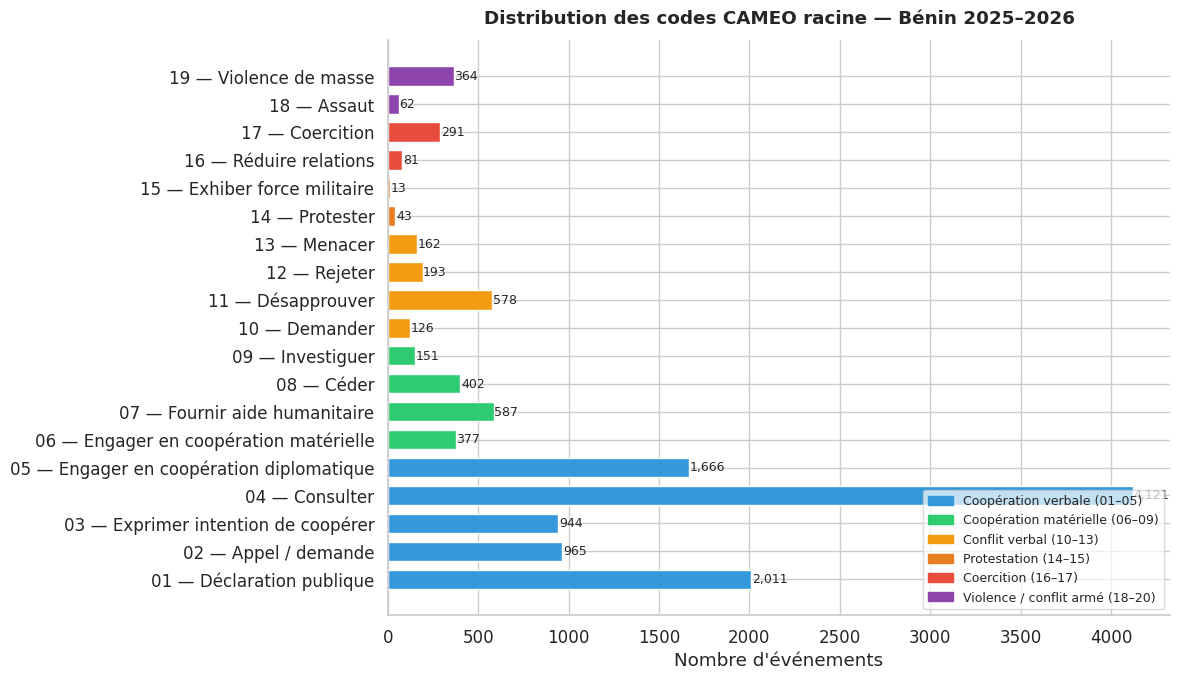

In [15]:
# ── Visualisation distribution CAMEO ──────────────────────────────────────
# Catégories de couleur selon la nature de l'événement
def cameo_color(code):
    c = int(code) if code.isdigit() else 0
    if c <= 5: return '#3498db'# Coopération verbale
    if c <= 9: return '#2ecc71'# Coopération matérielle
    if c <= 13: return '#f39c12'# Conflit verbal
    if c <= 15: return '#e67e22'# Protestation
    if c <= 17: return '#e74c3c'# Coercition
    return '#8e44ad'# Violence / conflit armé

code_counts = df['EventRootCode_str'].value_counts().sort_index()
labels = [f"{c} — {CAMEO_ROOT_LABELS.get(c, '?')}" for c in code_counts.index]
colors = [cameo_color(c) for c in code_counts.index]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(labels, code_counts.values, color=colors, height=0.7)
ax.set_xlabel("Nombre d'événements")
ax.set_title('Distribution des codes CAMEO racine — Bénin 2025–2026', fontweight='bold', pad=12)

# Légende catégories
from matplotlib.patches import Patch
legend_items = [
    Patch(color='#3498db', label='Coopération verbale (01–05)'),
    Patch(color='#2ecc71', label='Coopération matérielle (06–09)'),
    Patch(color='#f39c12', label='Conflit verbal (10–13)'),
    Patch(color='#e67e22', label='Protestation (14–15)'),
    Patch(color='#e74c3c', label='Coercition (16–17)'),
    Patch(color='#8e44ad', label='Violence / conflit armé (18–20)'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9, framealpha=0.7)

for bar, val in zip(bars, code_counts.values):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/viz_cameo_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Viz sauvegardée : ../docs/viz_cameo_distribution.png')

In [16]:
# ── Top 15 codes EventBaseCode (version fine, 3 chiffres) ─────────────────
print('Top 15 EventBaseCode (codes fins) :')
top_base = df['EventBaseCode'].value_counts().head(15)

# Quelques labels fins utiles pour le Bénin
BASE_CODE_LABELS = {
    '010': 'Déclaration publique',
    '040': 'Consultation (général)',
    '043': 'Demande coopération',
    '051': 'Appel à coopération',
    '060': 'Coopération (général)',
    '100': 'Demande (général)',
    '110': 'Désapprouver',
    '120': 'Rejeter',
    '130': 'Menacer',
    '140': 'Protester (général)',
    '143': 'Manifestation pacifique',
    '145': 'Émeute / violence protestation',
    '180': 'Violence (général)',
    '190': 'Violence de masse',
    '200': 'Armes non-conventionnelles',
}

top_base_df = pd.DataFrame({
    'EventBaseCode': top_base.index,
    'Nb_événements': top_base.values,
    'Label': [BASE_CODE_LABELS.get(str(c).zfill(3), '—') for c in top_base.index]
})
print(top_base_df.to_string(index=False))

Top 15 EventBaseCode (codes fins) :
 EventBaseCode  Nb_événements                  Label
            10           1429   Déclaration publique
            42           1420                      —
            43           1330    Demande coopération
            51           1079    Appel à coopération
            20            869                      —
            40            848 Consultation (général)
            36            631                      —
            46            457                      —
            57            350                      —
            71            281                      —
           190            245      Violence de masse
            70            208                      —
            61            199                      —
           112            197                      —
            30            190                      —


---
## 4 · Distribution des variables cibles ML

### `AvgTone` → variable cible du Modèle 1 (sentiment)
### `GoldsteinScale` → variable cible possible du Modèle 3 (régression)

In [17]:
# ── Stats descriptives des variables cibles ───────────────────────────────
target_cols = ['AvgTone', 'GoldsteinScale']
df[target_cols].describe().round(3)

,AvgTone,GoldsteinScale
count,13137.000,13137.000
mean,0.613,1.827
std,4.250,3.793
min,-21.865,-10.000
25%,-1.977,0.000
50%,1.145,2.800
75%,3.551,3.500
max,15.265,10.000


FileNotFoundError: [Errno 2] No such file or directory: '../docs/viz_target_distributions.png'

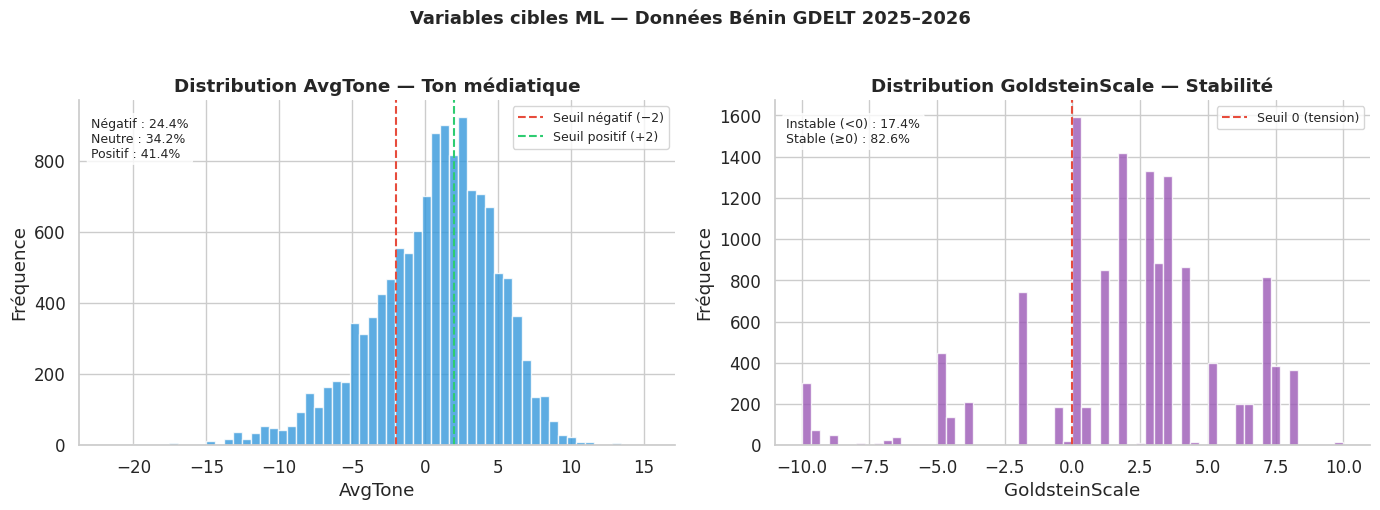

In [18]:
# ── Distributions AvgTone & GoldsteinScale ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- AvgTone
ax1 = axes[0]
ax1.hist(df['AvgTone'].dropna(), bins=60, color='#3498db', alpha=0.8, edgecolor='white')
ax1.axvline(-2, color='#e74c3c', linestyle='--', label='Seuil négatif (−2)')
ax1.axvline(+2, color='#2ecc71', linestyle='--', label='Seuil positif (+2)')
ax1.set_xlabel('AvgTone')
ax1.set_ylabel('Fréquence')
ax1.set_title('Distribution AvgTone — Ton médiatique', fontweight='bold')
ax1.legend(fontsize=9)

# Annotation des proportions par classe sentiment
n_total = df['AvgTone'].dropna()
pct_neg = (n_total < -2).mean() * 100
pct_neu = ((n_total >= -2) & (n_total <= 2)).mean() * 100
pct_pos = (n_total > 2).mean() * 100
ax1.text(0.02, 0.95, f'Négatif : {pct_neg:.1f}%\nNeutre : {pct_neu:.1f}%\nPositif : {pct_pos:.1f}%',
         transform=ax1.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# -- GoldsteinScale
ax2 = axes[1]
ax2.hist(df['GoldsteinScale'].dropna(), bins=60, color='#9b59b6', alpha=0.8, edgecolor='white')
ax2.axvline(0, color='#e74c3c', linestyle='--', label='Seuil 0 (tension)')
ax2.set_xlabel('GoldsteinScale')
ax2.set_ylabel('Fréquence')
ax2.set_title('Distribution GoldsteinScale — Stabilité', fontweight='bold')
ax2.legend(fontsize=9)

pct_instable = (df['GoldsteinScale'].dropna() < 0).mean() * 100
ax2.text(0.02, 0.95, f'Instable (<0) : {pct_instable:.1f}%\nStable (≥0) : {100-pct_instable:.1f}%',
         transform=ax2.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('Variables cibles ML — Données Bénin GDELT 2025–2026', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/viz_target_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Viz sauvegardée : ../docs/viz_target_distributions.png')

In [19]:
# ── Création des labels de sentiment (variable cible M1) ──────────────────
def label_sentiment(tone):
    if pd.isna(tone): return 'inconnu'if tone < -2: return 'négatif'if tone > 2: return 'positif'return 'neutre'df['sentiment_label'] = df['AvgTone'].apply(label_sentiment)

sent_counts = df['sentiment_label'].value_counts()
print('Distribution des classes de sentiment (Modèle 1) :')
print(sent_counts)
print()

# Vérification du déséquilibre de classes
ratio_min = sent_counts.min() / sent_counts.max()
if ratio_min < 0.3:
    print(f'Déséquilibre de classes détecté (ratio min/max = {ratio_min:.2f})')
    print('→ Prévoir class_weight="balanced" dans Scikit-learn ou SMOTE')
else:
    print(f' Classes relativement équilibrées (ratio min/max = {ratio_min:.2f})')

Distribution des classes de sentiment (Modèle 1) :
sentiment_label
positif    5440
neutre     4490
négatif    3207
Name: count, dtype: int64

✅ Classes relativement équilibrées (ratio min/max = 0.59)


---
## 5 · Distribution des features catégorielles clés

In [20]:
# ── Top pays source (Actor1CountryCode) ───────────────────────────────────
print('Top 15 pays source mentionnant le Bénin :')
top_countries = df['Actor1CountryCode'].value_counts().head(15)

# Codes FIPS → noms lisibles
COUNTRY_NAMES = {
    'BC': 'Bénin', 'FR': 'France', 'US': 'États-Unis', 'CN': 'Chine',
    'NI': 'Nigeria', 'TO': 'Togo', 'UV': 'Burkina Faso', 'NG': 'Niger',
    'GB': 'Royaume-Uni', 'GM': 'Allemagne', 'RS': 'Russie', 'CF': 'Congo',
    'SG': 'Sénégal', 'IV': 'Côte d\'Ivoire', 'GH': 'Ghana'
}
top_countries_df = pd.DataFrame({
    'Code': top_countries.index,
    'Pays': [COUNTRY_NAMES.get(str(c), str(c)) for c in top_countries.index],
    'Nb': top_countries.values,
    'Pct': (top_countries.values / len(df) * 100).round(1)
})
print(top_countries_df.to_string(index=False))

Top 15 pays source mentionnant le Bénin :
Code Pays   Nb  Pct
 BWA  BWA 4525 34.4
 AFR  AFR  867  6.6
 USA  USA  229  1.7
 ZWE  ZWE  204  1.6
 AGO  AGO  181  1.4
 GBR  GBR  135  1.0
 ZAF  ZAF  115  0.9
 NAM  NAM  111  0.8
 LSO  LSO  105  0.8
 SAF  SAF  103  0.8
 CHN  CHN   93  0.7
 ZMB  ZMB   75  0.6
 IND  IND   59  0.4
 NGA  NGA   49  0.4
 KEN  KEN   34  0.3


KeyError: 'Actor1Type1Code'

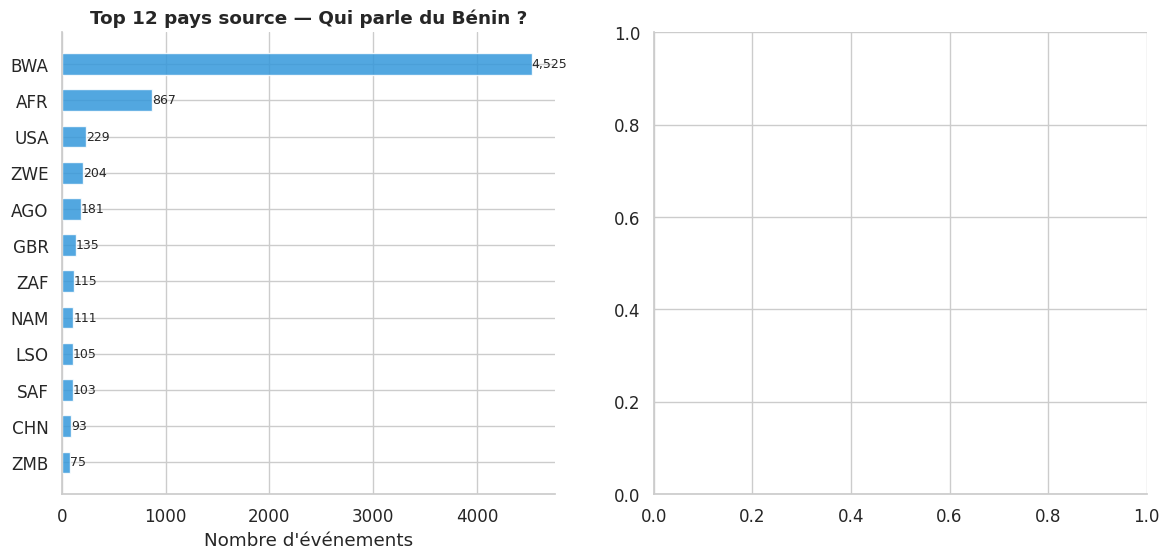

In [22]:
# ── Visualisation : top pays + types d'acteurs ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -- Top 12 pays source
ax1 = axes[0]
top12 = df['Actor1CountryCode'].value_counts().head(12)
labels_c = [COUNTRY_NAMES.get(str(c), str(c)) for c in top12.index]
bars = ax1.barh(labels_c[::-1], top12.values[::-1], color='#3498db', alpha=0.85, height=0.6)
ax1.set_xlabel("Nombre d'événements")
ax1.set_title('Top 12 pays source — Qui parle du Bénin ?', fontweight='bold')
for bar, val in zip(bars, top12.values[::-1]):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', ha='left', fontsize=9)

# -- Types d'acteurs (Actor1Type1Code)
ax2 = axes[1]
ACTOR_LABELS = {
    'GOV': 'Gouvernement', 'MIL': 'Militaire', 'REB': 'Rebelles',
    'OPP': 'Opposition', 'MED': 'Médias', 'NGO': 'ONG',
    'CVL': 'Civil', 'BUS': 'Entreprise', 'UAF': 'Forces armées'
}
top_actors = df['Actor1Type1Code'].value_counts().head(10)
labels_a = [ACTOR_LABELS.get(str(c), str(c)) for c in top_actors.index]
bars2 = ax2.barh(labels_a[::-1], top_actors.values[::-1], color='#9b59b6', alpha=0.85, height=0.6)
ax2.set_xlabel("Nombre d'événements")
ax2.set_title('Types d\'acteurs impliqués au Bénin', fontweight='bold')
for bar, val in zip(bars2, top_actors.values[::-1]):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', ha='left', fontsize=9)

plt.suptitle('Features catégorielles — Acteurs & pays source', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/viz_categorical_features.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Viz sauvegardée : ../docs/viz_categorical_features.png')

In [23]:
# ── Distribution géographique intra-Bénin (ActionGeo_ADM1Code) ────────────
ADM1_LABELS = {
    'BC01': 'Alibori (nord)', 'BC02': 'Atacora (nord)', 'BC03': 'Atlantique',
    'BC04': 'Borgou', 'BC05': 'Collines', 'BC06': 'Couffo',
    'BC07': 'Donga', 'BC08': 'Mono', 'BC09': 'Ouémé',
    'BC10': 'Plateau', 'BC11': 'Zou', 'BC12': 'Littoral (Cotonou)'
}
dept_counts = df['ActionGeo_ADM1Code'].value_counts().head(12)
dept_labels = [ADM1_LABELS.get(str(c), str(c)) for c in dept_counts.index]

print('Distribution des événements par département béninois :')
for code, label, count in zip(dept_counts.index, dept_labels, dept_counts.values):
    bar_len = int(count / dept_counts.max() * 30)
    print(f'{label:<25} {"█" * bar_len} {count:,}')

KeyError: 'ActionGeo_ADM1Code'

---
## 6 · Corrélations et relations inter-variables ML

FileNotFoundError: [Errno 2] No such file or directory: '../docs/viz_correlation_matrix.png'

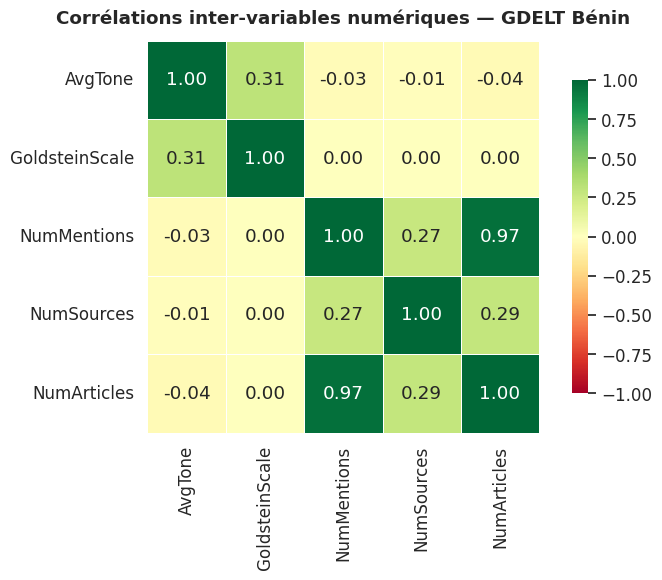

In [24]:
# ── Matrice de corrélation (variables numériques) ─────────────────────────
num_cols = ['AvgTone', 'GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 'QuadClass']
num_cols_present = [c for c in num_cols if c in df.columns]

corr_matrix = df[num_cols_present].corr().round(3)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Corrélations inter-variables numériques — GDELT Bénin', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../docs/viz_correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Viz sauvegardée : ../docs/viz_correlation_matrix.png')

In [25]:
# ── AvgTone moyen par code CAMEO racine ───────────────────────────────────
tone_by_cameo = (
    df.groupby('EventRootCode_label')['AvgTone']
    .agg(['mean', 'std', 'count'])
    .round(2)
    .sort_values('mean')
    .rename(columns={'mean': 'AvgTone_moyen', 'std': 'Écart-type', 'count': 'Nb_événements'})
)

print('AvgTone moyen par catégorie CAMEO (du plus négatif au plus positif) :')
print(tone_by_cameo[tone_by_cameo['Nb_événements'] > 10].to_string())

AvgTone moyen par catégorie CAMEO (du plus négatif au plus positif) :
                                     AvgTone_moyen  Écart-type  Nb_événements
EventRootCode_label                                                          
Assaut                                       -6.39        4.78             62
Coercition                                   -4.23        4.96            291
Menacer                                      -2.95        4.55            162
Désapprouver                                 -2.89        4.47            578
Violence de masse                            -2.71        4.90            364
Rejeter                                      -2.15        4.66            193
Investiguer                                  -1.53        3.88            151
Réduire relations                            -1.43        4.14             81
Protester                                    -1.31        4.72             43
Demander                                     -0.95        3.63          

In [26]:
# ── AvgTone moyen par pays source (top 10) ────────────────────────────────
tone_by_country = (
    df.groupby('Actor1CountryCode')['AvgTone']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'AvgTone_moyen', 'count': 'Nb_événements'})
    .query('Nb_événements >= 20')
    .sort_values('AvgTone_moyen')
    .round(2)
)
tone_by_country['Pays'] = [
    COUNTRY_NAMES.get(str(c), str(c)) for c in tone_by_country.index
]
print('Ton médiatique moyen par pays source (min. 20 événements) :')
print(tone_by_country[['Pays', 'AvgTone_moyen', 'Nb_événements']].to_string())

Ton médiatique moyen par pays source (min. 20 événements) :
                  Pays  AvgTone_moyen  Nb_événements
Actor1CountryCode                                   
ESP                ESP          -2.84             26
ZWE                ZWE          -1.40            204
ZAF                ZAF          -1.13            115
LSO                LSO          -0.44            105
GBR                GBR          -0.09            135
AUS                AUS           0.42             31
BWA                BWA           0.73           4525
USA                USA           0.81            229
AFR                AFR           0.98            867
ZMB                ZMB           1.08             75
SAF                SAF           1.49            103
NAM                NAM           1.65            111
SEN                SEN           1.71             27
CAN                CAN           1.95             28
ETH                ETH           2.02             22
TZA                TZA           2.09  

---
## 7 · Synthèse ML — Variables retenues & modèles recommandés

Ce récapitulatif est le livrable final du Jour 1 pour le ML Engineer.

In [27]:
# ── Rapport de synthèse automatique ──────────────────────────────────────
print('=' * 65)
print('SYNTHÈSE ML — EXPLORATION SCHÉMA GDELT BÉNIN')
print('iSHEERO × DataCamp Hackathon 2026')
print('=' * 65)

print(f'\n DATASET')
print(f'Événements analysés : {len(df):,}')
print(f'Période couverte : {df["SQLDATE"].min()} → {df["SQLDATE"].max()}')
print(f'Code pays : {COUNTRY_CODE} (Bénin)')
print(f'Codes CAMEO présents : {df["EventRootCode_str"].nunique()}/20')

print(f'\n VARIABLES CIBLES ML')
print(f'AvgTone → Modèle 1 (sentiment) : moy={df["AvgTone"].mean():.2f}, médiane={df["AvgTone"].median():.2f}')
print(f'GoldsteinScale → Modèle 3 (stabilité) : moy={df["GoldsteinScale"].mean():.2f}, médiane={df["GoldsteinScale"].median():.2f}')

print(f'\n CLASSES DE SENTIMENT (AvgTone)')
for label, count in df['sentiment_label'].value_counts().items():
    pct = count / len(df) * 100
    print(f'{label:<10} : {count:>5,} ({pct:.1f}%)')

print(f'\n VARIABLES RETENUES POUR LE FEATURE ENGINEERING (J2)')
features_plan = [
    ('EventRootCode', 'Encodage ordinal ou OHE', 'M1 · M2 · M3'),
    ('GoldsteinScale', 'Numérique direct', 'M2 · M3'),
    ('QuadClass', 'Ordinal 1–4', 'M2'),
    ('Actor1CountryCode', 'OHE top 15 + "autres"', 'M1 · M3'),
    ('Actor1Type1Code', 'OHE', 'M2 · M3'),
    ('ActionGeo_ADM1Code', 'OHE + flag nord/sud', 'M3'),
    ('NumMentions', 'Log-transform (skewed)', 'M3'),
    ('MONTHYEAR', 'Mois + trimestre extraits','M1 · M3'),
]
print(f'{"Colonne":<25} {"Traitement":<30} {"Modèle(s)"}')
print(f'{"-"*25} {"-"*30} {"-"*15}')
for col, treatment, models in features_plan:
    print(f'{col:<25} {treatment:<30} {models}')

print(f'\n MODÈLES RECOMMANDÉS (voir spécification ML J1)')
models_plan = [
    ('M1', 'Sentiment classification', 'TextBlob baseline + Scikit-learn', 'J2', 'Q1 · Q5'),
    ('M2', 'KMeans clustering', 'Scikit-learn KMeans (K=5)', 'J3', 'Q2 · Q5'),
    ('M3', 'Random Forest + Z-score', 'Scikit-learn RF + scipy', 'J4', 'Q3 · Q4 · Q5'),
]
for m_id, name, tools, day, questions in models_plan:
    print(f'[{m_id}] {name:<30} | {tools:<35} | Livrable: {day} | {questions}')

print(f'\n POINTS DE VIGILANCE POUR LE DATA ENGINEER (J2)')
null_critical = null_report[null_report['Null (%)'] > 20]
if len(null_critical) > 0:
    print('Colonnes avec > 20% de nulls à documenter :')
    for col in null_critical.index:
        if col in ML_COLS:
            print(f'{col} : {null_report.loc[col, "Null (%)"]:.1f}% de nulls')
else:
    print('Aucune colonne ML critique avec > 20% de nulls')

print(f'\n Notebook exécuté le : {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}')
print('=' * 65)

  SYNTHÈSE ML — EXPLORATION SCHÉMA GDELT BÉNIN
  iSHEERO × DataCamp Hackathon 2026

📦 DATASET
   Événements analysés   : 13,137
   Période couverte      : 20250101 → 20251231
   Code pays             : BC (Bénin)
   Codes CAMEO présents  : 19/20

🎯 VARIABLES CIBLES ML
   AvgTone       → Modèle 1 (sentiment) : moy=0.61, médiane=1.15
   GoldsteinScale → Modèle 3 (stabilité) : moy=1.83, médiane=2.80

📊 CLASSES DE SENTIMENT (AvgTone)
   positif    : 5,440 (41.4%)
   neutre     : 4,490 (34.2%)
   négatif    : 3,207 (24.4%)

⚙️  VARIABLES RETENUES POUR LE FEATURE ENGINEERING (J2)
   Colonne                   Traitement                     Modèle(s)
   ------------------------- ------------------------------ ---------------
   EventRootCode             Encodage ordinal ou OHE        M1 · M2 · M3
   GoldsteinScale            Numérique direct               M2 · M3
   QuadClass                 Ordinal 1–4                    M2
   Actor1CountryCode         OHE top 15 + "autres"          M1 · M3
 

In [28]:
# ── Sauvegarde optionnelle d'un échantillon local pour les tests offline ──
SAVE_SAMPLE = True # ← Mettre False pour ne pas sauvegarder

if SAVE_SAMPLE:
    import os
    os.makedirs('../data/raw', exist_ok=True)
    sample_path = '../data/raw/benin_raw.csv'df.to_csv(sample_path, index=False)
    size_mb = os.path.getsize(sample_path) / 1e6
    print(f' Échantillon sauvegardé : {sample_path} ({size_mb:.1f} MB)')
    print('→ Partagez ce fichier sur WhatsApp ou Google Drive avec l\'équipe')
    print('→ Le Data Engineer peut utiliser ce fichier comme base pour benin_clean.csv')

💾 Échantillon sauvegardé : ../data/raw/benin_raw.csv (2.8 MB)
   → Partagez ce fichier sur WhatsApp ou Google Drive avec l'équipe
   → Le Data Engineer peut utiliser ce fichier comme base pour benin_clean.csv


---

## R?capitulatif des livrables J1 ? ML Engineer

| Livrable | Statut | Localisation |
|----------|--------|--------------|
| Ce notebook ex?cut? sans erreur | OK | `notebooks/00_schema_exploration.ipynb` |
| `viz_nulls_ml_columns.png` | OK | `docs/` |
| `viz_cameo_distribution.png` | OK | `docs/` |
| `viz_target_distributions.png` | OK | `docs/` |
| `viz_categorical_features.png` | OK | `docs/` |
| `viz_correlation_matrix.png` | OK | `docs/` |
| `benin_raw.csv` (?chantillon local) | OK | `data/raw/` |
| Sp?cification ML (3 mod?les justifi?s) | OK | Partag? en ?quipe |

---

*iSHEERO ? DataCamp Hackathon 2026 ? B?nin Insights Challenge*
